In [1]:
%load_ext autoreload
%autoreload 2

import os
import x4c  # https://ncar.github.io/x4c/
import pandas as pd
import numpy as np
print(x4c.__version__)
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')
import xarray as xr

2026.6.11


In [3]:
d18Osw = {}
# for tag in ['PI', '1.5x', '3x']:
for tag in ['1.5x', '3x']:
    d18Osw[tag] = xr.open_dataarray(f'../data/iCESM1.3_{tag}_d18Osw_climo.nc')

dz = xr.open_dataarray(f'../data/iCESM1.3_dz.nc')
gw = xr.open_dataarray(f'../data/iCESM1.3_TAREA.nc')

In [4]:
diff = d18Osw['3x'].mean('time') - d18Osw['1.5x'].mean('time')
diff.attrs['dz'] = dz
diff.attrs['gw'] = gw
diff.name = 'd18Osw'

diff_bw = diff.x.zavg(3e5, None)

In [5]:
diff_bw_gm = diff_bw.x.gm
print(f'Global Mean d18Osw Diff (3x - 1.5x): {diff_bw_gm:.4f} permil VSMOW')

Global Mean d18Osw Diff (3x - 1.5x): -0.0243 permil VSMOW


In [6]:
df_sites = pd.read_csv('../data/df_d18Ob_sites_MCO.csv')

/glade/derecho/scratch/fengzhu/tmp/ipykernel_122830/3701757454.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  site_diff.append(float(v.values))
/glade/derecho/scratch/fengzhu/tmp/ipykernel_122830/3701757454.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  site_diff.append(float(v.values))
/glade/derecho/scratch/fengzhu/tmp/ipykernel_122830/3701757454.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  site_diff.append(float(v.values))
/glade/derecho/scra

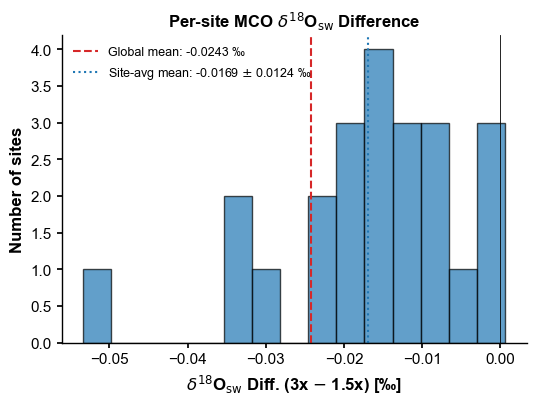

Figure saved at: "../figs/SIFig.06_per_site_hist.pdf"


In [7]:
import matplotlib.pyplot as plt

# sample the model anomaly at each site's paleo coordinate
site_diff = []
for _, row in df_sites.iterrows():
    v = diff_bw.x.nearest2d(
        lat=row['paleo_lat'], lon=row['paleo_lon'],
        lat_dim='nlat', lon_dim='nlon',
        lat_coord='TLAT', lon_coord='TLONG',
    )
    site_diff.append(float(v.values))
site_diff = np.array(site_diff)

site_avg = float(site_diff.mean())
site_std = float(site_diff.std(ddof=1))

x4c.set_style('journal_nogrid', font_scale=1.0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(site_diff, bins=15, color='tab:blue', alpha=0.7, edgecolor='k')
ax.axvline(0, color='k', lw=0.6)
ax.axvline(diff_bw_gm, color='tab:red', ls='--', lw=1.5,
           label=f'Global mean: {diff_bw_gm:.4f} ‰')
ax.axvline(site_avg, color='tab:blue', ls=':', lw=1.5,
           label=f'Site-avg mean: {site_avg:.4f} $\\pm$ {site_std:.4f} ‰')
ax.set_xlabel(r'$\delta^{18}$O$_{\text{sw}}$ Diff. (3x $-$ 1.5x) [‰]', weight='bold')
ax.set_ylabel('Number of sites', weight='bold')
ax.set_title(r'Per-site MCO $\delta^{18}$O$_{\text{sw}}$ Difference', weight='bold')
ax.legend(loc='upper left', frameon=False, fontsize=9)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.06_per_site_hist.pdf')

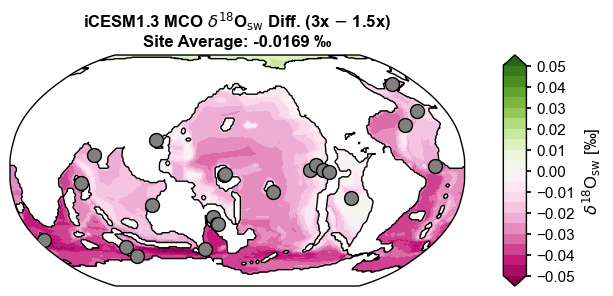

Figure saved at: "../figs/SIFig.06.pdf"


In [9]:
ms = 100
fig, ax = diff_bw.x.regrid().x.plot(
    # title=r'iCESM1.3 MCO $\delta^{18}$O$_{\text{sw}}$ Diff. (3x $-$ 1.5x)'+f'\nGlobal Mean: {diff_bw_gm:.4f} ‰, Site Average: {site_avg:.4f} ‰',
    title=r'iCESM1.3 MCO $\delta^{18}$O$_{\text{sw}}$ Diff. (3x $-$ 1.5x)'+f'\nSite Average: {site_avg:.4f} ‰',
    levels=np.linspace(-0.05, 0.05, 21),
    cbar_kwargs={
        'label': r'$\delta^{18}$O$_{\text{sw}}$ [‰]',
        'ticks': np.linspace(-0.05, 0.05, 11),
    },
    cmap='PiYG',
    df_sites=df_sites,
    site_markersizes=ms,
    legend=False,
    colname_dict={
        'lat': 'paleo_lat',
        'lon': 'paleo_lon',
    }, 
)

x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.06.pdf')